In [115]:
import torch
import torchvision.models as models
from torchvision import transforms
import os

# import faiss
import numpy as np
from PIL import Image

data_dir = "dataset"

# Functions 

In [117]:
import matplotlib.pyplot as plt
from PIL import Image


def plot_images(indices, files):
    fig, ax = plt.subplots(1, len(indices))

    for i, idx in enumerate(indices):
        im = Image.open(files[idx])
        ax[i].imshow(im)

## MODEL

In [ ]:
# Загрузка модели
model = models.resnet101(pretrained=True)
model.eval()

# Препроцессинг изображения
preprocess = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


# Извлечение признаков
def get_embedding(image_path):
    img = Image.open(image_path).convert("RGB")
    img_tensor = preprocess(img).unsqueeze(0)
    with torch.no_grad():
        embedding = model(img_tensor)
    return embedding.numpy().flatten()

c:\Users\anton\.virtualenvs\03.14_ml-yandex_3.0-9PhsjchO\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\anton\.virtualenvs\03.14_ml-yandex_3.0-9PhsjchO\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [127]:
from tqdm import tqdm

# Получаем эмбеддинги для всех изображений
image_paths = [
    os.path.join(data_dir, entry.name)
    for entry in os.scandir(data_dir)
    if entry.is_file()
]  # список путей к изображениям

In [128]:
emb = get_embedding(image_paths[0])
emb.shape

(1000,)

In [129]:
embeddings = []

for path in tqdm(image_paths):
    emb = get_embedding(path)
    embeddings.append(emb)
embeddings = np.array(embeddings)

100%|██████████| 9605/9605 [41:47<00:00,  3.83it/s]


In [140]:
from sklearn.neighbors import NearestNeighbors
import numpy as np


def cosine_distance(a, b):
    return 1 - np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


nn = NearestNeighbors(
    n_neighbors=7,
    algorithm="brute",  # Только brute-force поддерживает кастомные метрики
    metric=cosine_distance,
)
nn.fit(embeddings)

NearestNeighbors(algorithm='brute',
                 metric=<function cosine_distance at 0x00000235AFCB1B20>,
                 n_neighbors=7)

### EMBEDINGS CHECKS

In [141]:
embeddings.shape

(9605, 1000)

In [139]:
# Поиск для одного изображения (пример)
query = embeddings[0].reshape(1, -1)
print(query.shape)
nn.kneighbors(query)

(1, 1000)


(array([[0.        , 0.17016238, 0.22277856, 0.24146283, 0.24169987,
         0.24240267]]),
 array([[   0, 8222, 4932, 5207, 8987, 6448]]))

In [142]:
distances, indices = nn.kneighbors(embeddings[:])

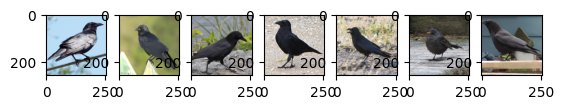

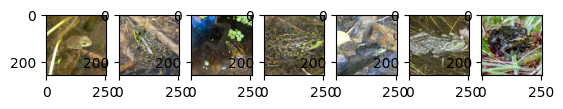

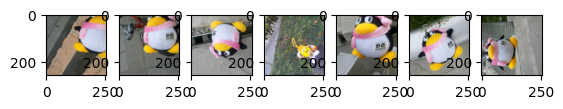

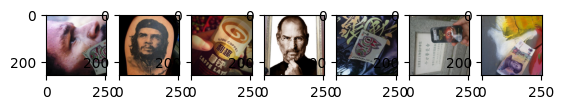

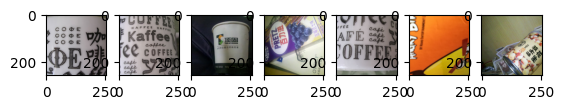

In [143]:
for i in range(5):
    plot_images(indices=indices[i], files=image_paths)

In [144]:
# # Строим индекс FAISS
# index = faiss.IndexFlatL2(embeddings.shape[1])
# index.add(embeddings)

# Поиск 6 ближайших соседей (исключая само изображение)
# D, I = index.search(embeddings, k)
results = {}
for i, path in enumerate(image_paths):
    neighbors = [
        image_paths[i] for i in indices[i][1:]
    ]  # пропускаем первый (само изображение)
    results[path] = neighbors

In [145]:
import csv

with open("submission.csv", "w", newline="") as f:  # newline='' убирает лишние переносы
    writer = csv.writer(
        f, delimiter=",", quoting=csv.QUOTE_MINIMAL
    )  # явно указываем параметры

    # Записываем заголовок без пробелов
    writer.writerow(["filename", "ranking"])

    for path, neighbors in results.items():
        # Формируем строку без пробелов вокруг запятых
        filename = path.split("\\")[-1]
        ranking = " ".join(n.split("\\")[-1] for n in neighbors)
        writer.writerow([filename, ranking])  # передаем как список

In [151]:
indices[0:10]

array([[   0, 8222, 4932, 5207, 8987, 6448, 9405],
       [   1, 5029, 6470, 5193, 1149, 3598, 3986],
       [   2, 7688, 3977, 5786, 5492, 2448, 1858],
       [   3, 1113, 9091, 7087, 1051, 6438, 9219],
       [   4, 4593, 2607, 1855, 4191, 7403, 5066],
       [   5, 1053, 7140, 1862, 1750, 4895, 5530],
       [   6, 3057, 2561, 4407, 2655, 8196, 6148],
       [   7, 4321, 2174, 4661, 9066, 6145, 6094],
       [   8, 1310, 8385,  206,  217, 6388, 3206],
       [   9, 4653, 4247,  854, 1539, 8189, 7942]])

In [148]:
distances[0]

array([0.        , 0.17016238, 0.22277856, 0.24146283, 0.24169987,
       0.24240267, 0.25059885])